# Arandu examples

Set `ARANDU_USERNAME` and `ARANDU_PASSWORD` in your environment before running this notebook. Queries use AstroQL. Spatial coordinates and radii are in degrees; source dates are MJD TAI.

In [1]:
from arandu import AranduClient

client = AranduClient()

## A cone search

`cone_search` builds an AstroQL `cone(ra, dec, center_ra, center_dec, radius)` clause.

In [2]:
objects = client.cone_search(
    'arandu.dia_object',
    ra=277.48425,
    dec=13.5576,
    radius_deg=180 / 3600,
    limit=1_000,
)
objects.head()

Check query status at: https://ai-scope.cbpf.br/queries/ed2a9572-713d-4cb5-8b31-237b179cd77b
Results fetched.


,dia_object_id,ra,dec,ra_err,dec_err,n_dia_sources,first_dia_source_mjd_tai,last_dia_source_mjd_tai,validity_start_mjd_tai,f062_psf_flux_mean,...,f184_psf_flux_mean,f184_psf_flux_sigma,f184_psf_flux_ndata,f184_psf_flux_min,f184_psf_flux_max,f213_psf_flux_mean,f213_psf_flux_sigma,f213_psf_flux_ndata,f213_psf_flux_min,f213_psf_flux_max
0,52348240,277.466422,13.526918,None,None,7,61213.362492,61318.207437,61318.207437,327.88312,...,4498.279,0.0,1,4498.279,4498.279,None,None,None,None,None


## A polygon search

Pass three or more `(ra, dec)` vertices in boundary order.

In [3]:
polygon_objects = client.polygon_search(
    'arandu.dia_object',
    [(277.40, 13.50), (277.60, 13.50), (277.60, 13.70), (277.40, 13.70)],
    limit=1_000,
)
polygon_objects.head()

Check query status at: https://ai-scope.cbpf.br/queries/396cf26c-498c-47c1-b1ce-d704ac1c33e0
Results fetched.


,dia_object_id,ra,dec,ra_err,dec_err,n_dia_sources,first_dia_source_mjd_tai,last_dia_source_mjd_tai,validity_start_mjd_tai,f062_psf_flux_mean,...,f184_psf_flux_mean,f184_psf_flux_sigma,f184_psf_flux_ndata,f184_psf_flux_min,f184_psf_flux_max,f213_psf_flux_mean,f213_psf_flux_sigma,f213_psf_flux_ndata,f213_psf_flux_min,f213_psf_flux_max
0,96023210,277.458029,13.612504,None,None,7,61208.023197,61297.837914,61297.837914,114.40698,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,78211083,277.576909,13.587346,None,None,19,61184.548933,61300.636172,61300.636172,219.75096,...,274.99695,0.645866,4.0,274.61865,276.11557,NaN,NaN,NaN,NaN,NaN
2,80452811,277.435369,13.598894,None,None,16,61197.498589,61306.965243,61306.965243,NaN,...,310.60504,10.922928,3.0,302.82962,326.05230,2270.1292,657.83660,3.0,1484.60130,3094.5562
3,50939728,277.567903,13.502012,None,None,19,61195.039193,61307.274552,61307.274552,693.26320,...,191.57524,49.006294,3.0,129.20323,248.92850,1003.9353,512.49450,4.0,147.76738,1484.7538
4,49951929,277.428926,13.537970,None,None,17,61192.916688,61310.471698,61310.471698,2321.44850,...,224.78100,0.000000,1.0,224.78100,224.78100,1145.4231,246.38618,2.0,899.03690,1391.8092


## Download a date range and larger results

`sources_by_date` selects `midpoint_mjd_tai`. For large results, use date intervals: each request directly filters the indexed time column, without `OFFSET` or a global sort.

In [4]:
sources = client.sources_by_date(60000, 60001, limit=50_000)
sources.head()

Check query status at: https://ai-scope.cbpf.br/queries/0107b0f3-140d-4b3a-9e8e-0d250f6a0956
Results fetched.


,dia_source_id,visit,detector,dia_object_id,ss_object_id,parent_dia_source_id,midpoint_mjd_tai,ra,dec,ra_err,...,expid,isdiffpos,qfit,cfit,redchi,npixfit,sharpness,roundness1,roundness2,peak


In [ ]:
for batch in client.sources_by_date_batches(
    60000, 60010,
    interval_days=1,
):
    # Save or process each date interval here.
    print(f'Received {len(batch):,} rows')

## Display alert cutouts

Provide an alert from the broker (or an alert ID). The helper uses a URL published in `alert['payload']['cutouts']` when available, otherwise it uses the standard cutout endpoint.

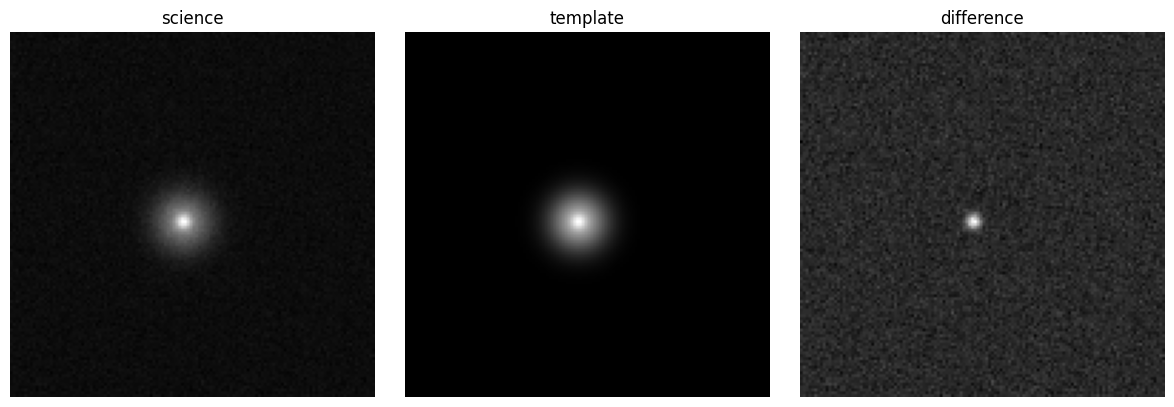

In [6]:
import matplotlib.pyplot as plt
from arandu import CUTOUT_KINDS, download_cutout

# Replace this with an alert returned by the broker.
alert = {'alert_id': 9514770633}

fig, axes = plt.subplots(1, len(CUTOUT_KINDS), figsize=(12, 4))
for axis, kind in zip(axes, CUTOUT_KINDS):
    image = download_cutout(alert, kind)
    axis.imshow(image, origin='lower', cmap='gray')
    axis.set_title(kind)
    axis.set_axis_off()
plt.tight_layout()